# Загрузка данных

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Данные взяты с сайта kaggle
[банковские транзакции](https://www.kaggle.com/datasets/shivamb/bank-customer-segmentation)

In [ ]:
import pandas as pd
bank_clients_transactions = pd.read_csv('/content/drive/MyDrive/Python_colab/Lesson_14/bank_clients_transactions.csv')

In [ ]:
bank_clients_transactions

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5
...,...,...,...,...,...,...,...,...,...
1048562,T1048563,C8020229,8/4/90,M,NEW DELHI,7635.19,18/9/16,184824,799.0
1048563,T1048564,C6459278,20/2/92,M,NASHIK,27311.42,18/9/16,183734,460.0
1048564,T1048565,C6412354,18/5/89,M,HYDERABAD,221757.06,18/9/16,183313,770.0
1048565,T1048566,C6420483,30/8/78,M,VISAKHAPATNAM,10117.87,18/9/16,184706,1000.0


In [ ]:
bank_clients_transactions.columns

Index(['TransactionID', 'CustomerID', 'CustomerDOB', 'CustGender',
       'CustLocation', 'CustAccountBalance', 'TransactionDate',
       'TransactionTime', 'TransactionAmount (INR)'],
      dtype='object')

# Приведение столбцов к стилю camel_case

In [ ]:
def to_camel_case_preserve_case(column_name):
    import re
    # Разделяем по не-буквенным символам, но сохраняем регистр слов
    words = re.findall(r'[A-Za-z][a-z]*|[A-Z]+(?=[A-Z]|$)|[0-9]+', column_name)

    if not words:
        return column_name

    result = words[0].lower()
    for word in words[1:]:
        # Если слово уже в верхнем регистре (аббревиатура), оставляем как есть
        if word.isupper():
            result += word
        else:
            result += word.capitalize()
    return result

bank_clients_transactions.columns = [to_camel_case_preserve_case(col) for col in bank_clients_transactions.columns]

In [ ]:
bank_clients_transactions.columns

Index(['transactionID', 'customerID', 'customerDOB', 'custGender',
       'custLocation', 'custAccountBalance', 'transactionDate',
       'transactionTime', 'transactionAmountINR'],
      dtype='object')

# Приведение типов данных

In [ ]:
bank_clients_transactions['transactionDate'] = pd.to_datetime(bank_clients_transactions['transactionDate'])
bank_clients_transactions['customerDOB'] = pd.to_datetime(bank_clients_transactions['customerDOB'])

/tmp/ipython-input-3584940193.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bank_clients_transactions['transactionDate'] = pd.to_datetime(bank_clients_transactions['transactionDate'])
/tmp/ipython-input-3584940193.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bank_clients_transactions['customerDOB'] = pd.to_datetime(bank_clients_transactions['customerDOB'])


In [ ]:
bank_clients_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   transactionID         1048567 non-null  object        
 1   customerID            1048567 non-null  object        
 2   customerDOB           1045170 non-null  datetime64[ns]
 3   custGender            1047467 non-null  object        
 4   custLocation          1048416 non-null  object        
 5   custAccountBalance    1046198 non-null  float64       
 6   transactionDate       1048567 non-null  datetime64[ns]
 7   transactionTime       1048567 non-null  int64         
 8   transactionAmountINR  1048567 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(4)
memory usage: 72.0+ MB


# Поиск дублей и пропусков в данных

In [ ]:
bank_clients_transactions = bank_clients_transactions.drop_duplicates()
bank_clients_transactions = bank_clients_transactions.dropna()

# Исследовательский анализ данных

In [ ]:
bank_clients_transactions

,transactionID,customerID,customerDOB,custGender,custLocation,custAccountBalance,transactionDate,transactionTime,transactionAmountINR
0,T1,C5841053,1994-10-01,F,JAMSHEDPUR,17819.05,2016-02-08,143207,25.0
1,T2,C2142763,2057-04-04,M,JHAJJAR,2270.69,2016-02-08,141858,27999.0
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-02-08,142712,459.0
3,T4,C5342380,2073-09-14,F,MUMBAI,866503.21,2016-02-08,142714,2060.0
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-02-08,181156,1762.5
...,...,...,...,...,...,...,...,...,...
1048562,T1048563,C8020229,1990-08-04,M,NEW DELHI,7635.19,2016-09-18,184824,799.0
1048563,T1048564,C6459278,1992-02-20,M,NASHIK,27311.42,2016-09-18,183734,460.0
1048564,T1048565,C6412354,1989-05-18,M,HYDERABAD,221757.06,2016-09-18,183313,770.0
1048565,T1048566,C6420483,1978-08-30,M,VISAKHAPATNAM,10117.87,2016-09-18,184706,1000.0


Уникальных клиентов: 879358


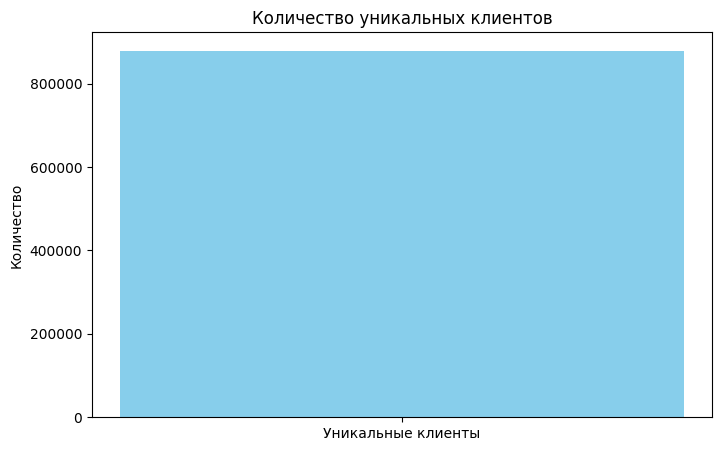

In [ ]:
# сколько уникальных клиентов?
import matplotlib.pyplot as plt

unique_clients = bank_clients_transactions['customerID'].nunique()
print(f'Уникальных клиентов: {unique_clients}')

plt.figure(figsize=(8, 5))
plt.bar(['Уникальные клиенты'], [unique_clients], color='skyblue')
plt.title('Количество уникальных клиентов')
plt.ylabel('Количество')
plt.show()

In [ ]:
# какое количество транзакций было совершено?
total_transactions = len(bank_clients_transactions)
print(f'Всего транзакций: {total_transactions}')

Всего транзакций: 1041614


Среднее количество транзакций на одного клиента: 1.18


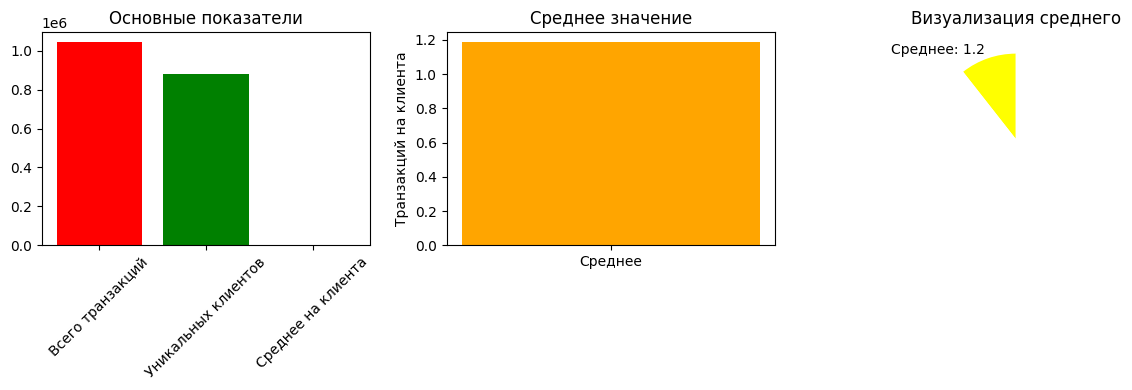

In [ ]:
# сколько в среднем транзакций приходится на одного клиента?
average_transactions = len(bank_clients_transactions) / bank_clients_transactions['customerID'].nunique()
print(f'Среднее количество транзакций на одного клиента: {average_transactions:.2f}')

labels = ['Всего транзакций', 'Уникальных клиентов', 'Среднее на клиента']
values = [total_transactions, unique_clients, average_transactions]

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.bar(labels, values, color=['red', 'green', 'blue'])
plt.title('Основные показатели')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
plt.bar(['Среднее'], [average_transactions], color='orange')
plt.ylabel('Транзакций на клиента')
plt.title('Среднее значение')

plt.subplot(1, 3, 3)
plt.pie([average_transactions, 10], labels=[f'Среднее: {average_transactions:.1f}', ''],
        colors=['yellow', 'white'], startangle=90)
plt.title('Визуализация среднего')

plt.tight_layout()
plt.show()

БАЛАНС:
От 0.00 до 115035495.10
В среднем: 114998.61

ТРАНЗАКЦИИ:
От 0.00 до 1560034.99
В среднем: 1566.10


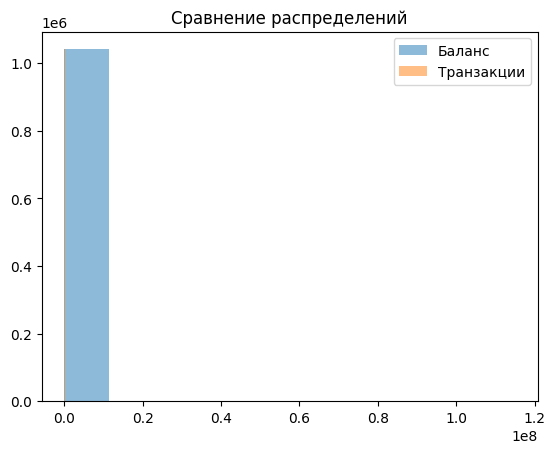

In [ ]:
# изучить распределение и размах величин CustAccountBalance и TransactionAmount
balance = bank_clients_transactions['custAccountBalance']
transactions = bank_clients_transactions['transactionAmountINR']

print('БАЛАНС:')
print(f'От {balance.min():.2f} до {balance.max():.2f}')
print(f'В среднем: {balance.mean():.2f}')

print('\nТРАНЗАКЦИИ:')
print(f'От {transactions.min():.2f} до {transactions.max():.2f}')
print(f'В среднем: {transactions.mean():.2f}')

plt.hist(balance, alpha=0.5, label='Баланс')
plt.hist(transactions, alpha=0.5, label='Транзакции')
plt.legend()
plt.title('Сравнение распределений')
plt.show()

ВОЗРАСТ КЛИЕНТОВ:
Самый молодой: -49 лет
Самый старший: 225 лет
Средний возраст: 40.0 лет


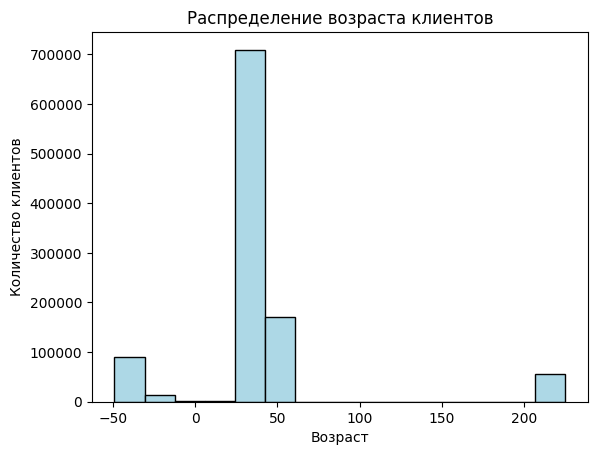

In [ ]:
# анализ возраста клиентов
from datetime import datetime

current_year = datetime.now().year
bank_clients_transactions['customerAge'] = current_year - pd.to_datetime(
    bank_clients_transactions['customerDOB'], format='%d/%m/%y'
).dt.year

ages = bank_clients_transactions['customerAge']
print('ВОЗРАСТ КЛИЕНТОВ:')
print(f'Самый молодой: {ages.min()} лет')
print(f'Самый старший: {ages.max()} лет')
print(f'Средний возраст: {ages.mean():.1f} лет')

# Простая визуализация
plt.hist(ages, bins=15, color='lightblue', edgecolor='black')
plt.title('Распределение возраста клиентов')
plt.xlabel('Возраст')
plt.ylabel('Количество клиентов')
plt.show()

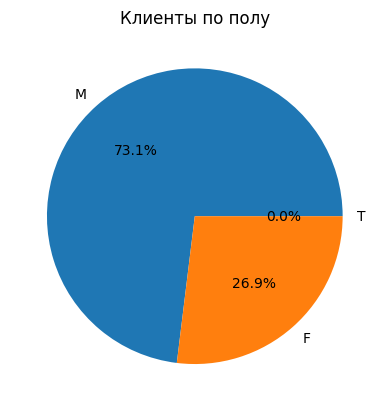

Мужчины: 760978
Женщины: 280635


In [ ]:
# изучить пол клиентов (визуализировать)
gender_counts = bank_clients_transactions['custGender'].value_counts()

plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
plt.title('Клиенты по полу')
plt.show()

print(f'Мужчины: {gender_counts.get('M', 0)}')
print(f'Женщины: {gender_counts.get('F', 0)}')

    ТОП-25 ГОРОДОВ ПО КОЛИЧЕСТВУ КЛИЕНТОВ    
Всего городов в базе: {len(city_clients)}
Показываем топ-25 городов
Всего уникальных клиентов: 1033673


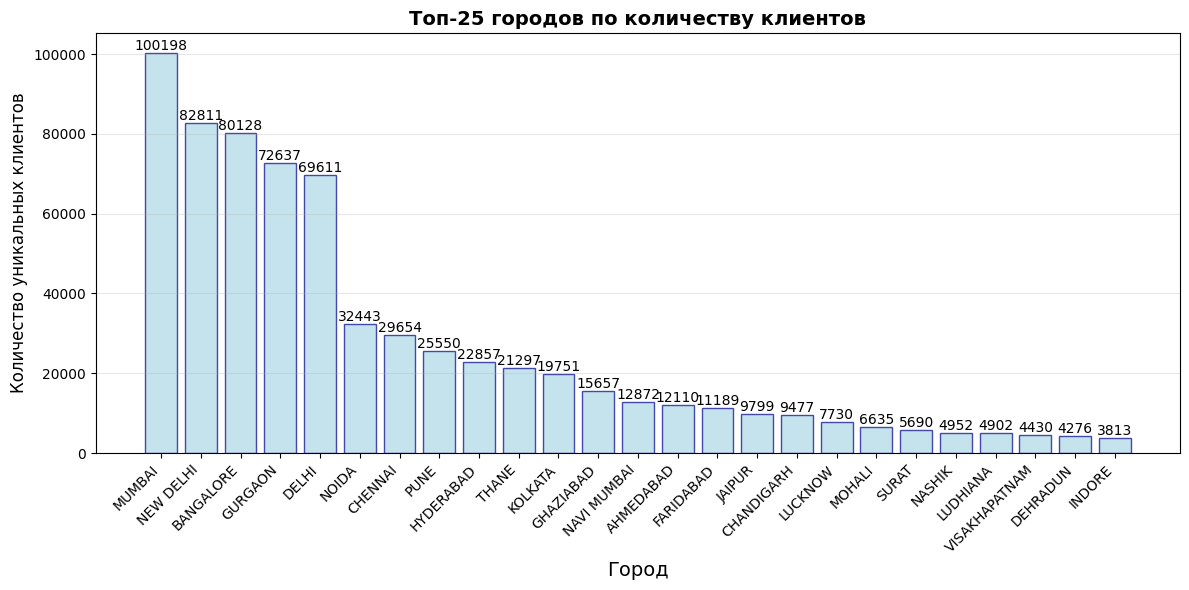

In [ ]:
# изучить место жительства клиентов (визуализировать)
city_clients = bank_clients_transactions.groupby('custLocation')['customerID'].nunique()

top_cities = city_clients.sort_values(ascending=False).head(25)

print('    ТОП-25 ГОРОДОВ ПО КОЛИЧЕСТВУ КЛИЕНТОВ    ')
print('Всего городов в базе: {len(city_clients)}')
print(f'Показываем топ-25 городов')
print(f'Всего уникальных клиентов: {city_clients.sum()}')

plt.figure(figsize=(12, 6))
bars = plt.bar(top_cities.index, top_cities.values,
               color='lightblue', edgecolor='darkblue', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{int(height)}', ha='center', va='bottom', fontsize=10)

plt.title('Топ-25 городов по количеству клиентов', fontsize=14, fontweight='bold')
plt.xlabel('Город', fontsize=14)
plt.ylabel('Количество уникальных клиентов', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

    ДИНАМИКА ТРАНЗАКЦИЙ ПО ДНЯМ    
Период анализа: от 2016-01-08 до 2016-12-09
Всего дней в данных: 55
Среднее количество транзакций в день: 18938.4


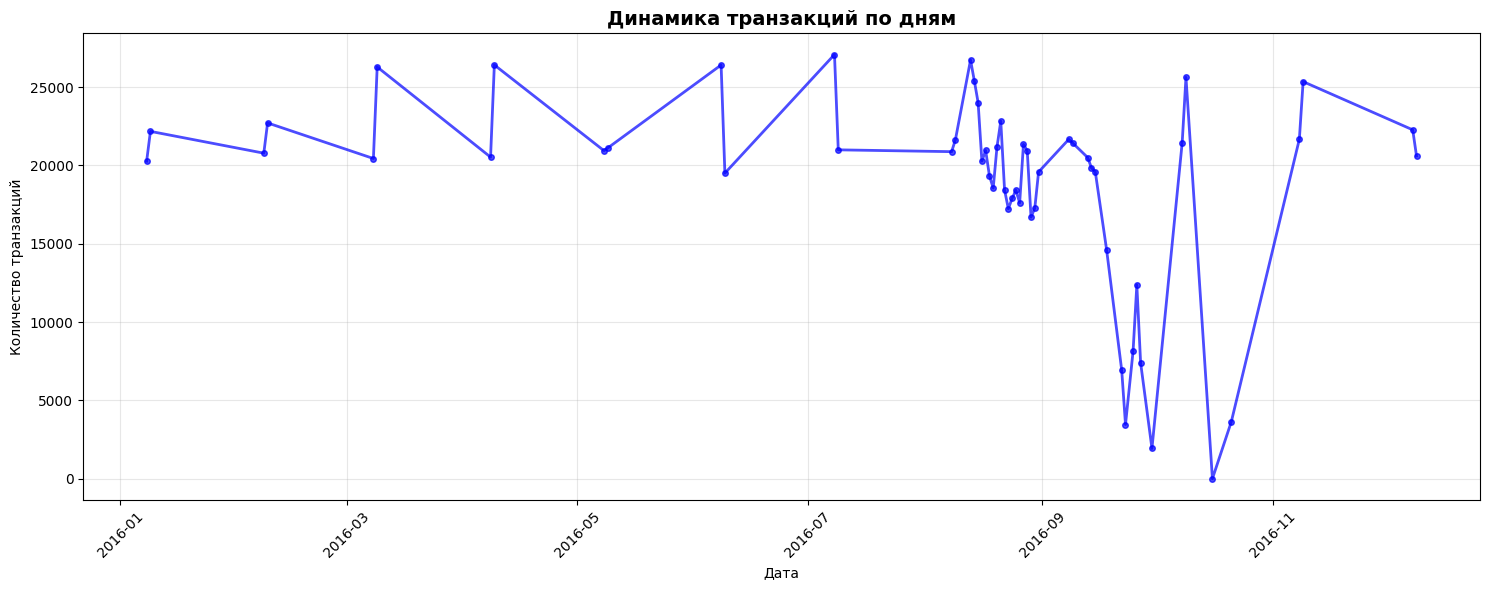

In [ ]:
# посмотреть динамику транзакций по дате (в кол-ве TransactionID)
daily_transactions = bank_clients_transactions.groupby(
    bank_clients_transactions['transactionDate'].dt.date
)['transactionID'].count()

print('    ДИНАМИКА ТРАНЗАКЦИЙ ПО ДНЯМ    ')
print(f'Период анализа: от {daily_transactions.index.min()} до {daily_transactions.index.max()}')
print(f'Всего дней в данных: {len(daily_transactions)}')
print(f'Среднее количество транзакций в день: {daily_transactions.mean():.1f}')

# Линейный график по дням
plt.figure(figsize=(15, 6))
plt.plot(daily_transactions.index, daily_transactions.values,
         marker='o', linewidth=2, markersize=4, color='blue', alpha=0.7)
plt.title('Динамика транзакций по дням', fontsize=14, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Количество транзакций')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

    ДИНАМИКА СУММЫ ПРОДАЖ ПО МЕСЯЦАМ    
Период анализа: 2016-01 - 2016-12


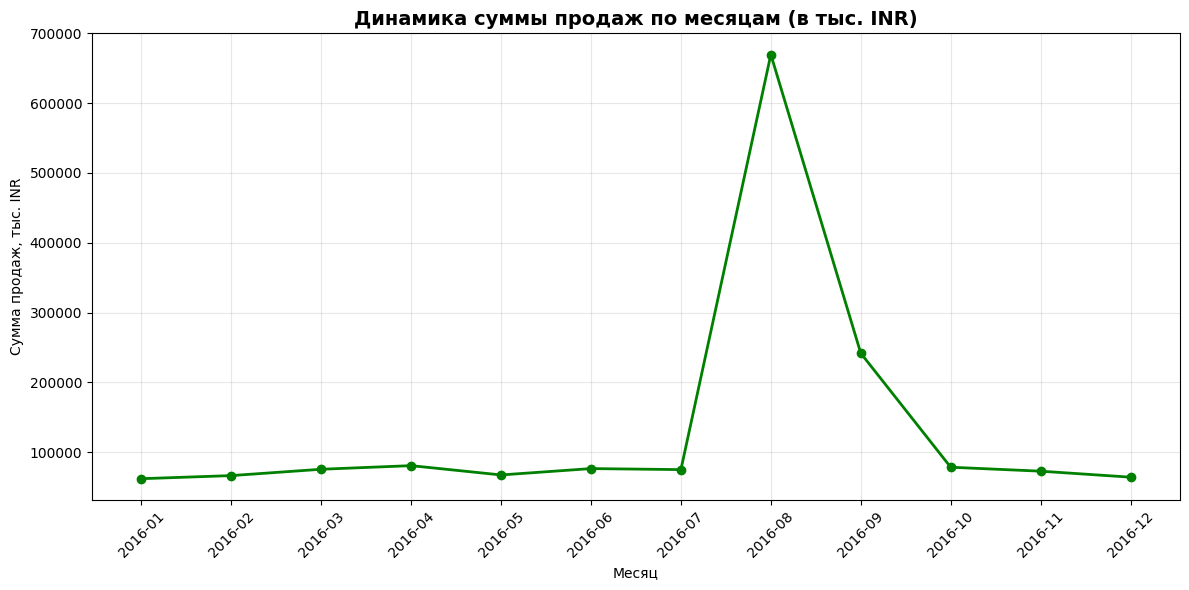

In [ ]:
# посмотреть динамику транзакций по дате (в сумме TransactionAmount)
monthly_sales = bank_clients_transactions.groupby(
    bank_clients_transactions['transactionDate'].dt.to_period('M')
)['transactionAmountINR'].sum()

print('    ДИНАМИКА СУММЫ ПРОДАЖ ПО МЕСЯЦАМ    ')
print(f'Период анализа: {monthly_sales.index.min()} - {monthly_sales.index.max()}')

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values / 1000,
         marker='o', linewidth=2, markersize=6, color='green')
plt.title('Динамика суммы продаж по месяцам (в тыс. INR)', fontsize=14, fontweight='bold')
plt.xlabel('Месяц')
plt.ylabel('Сумма продаж, тыс. INR')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipython-input-3430678943.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_groups = bank_clients_transactions.groupby('ageGroup')['transactionAmountINR'].agg(['sum', 'count'])
/tmp/ipython-input-3430678943.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_groups['avg_per_client'] = age_groups['sum'] / bank_clients_transactions.groupby('ageGroup')['customerID'].nunique()


Платежеспособность возрастных групп:
                   sum   count  avg_per_client
ageGroup                                      
<18       5.419403e+05     186     2913.657527
18-24     8.527996e+05     481     1772.972121
25-34     2.310804e+08  270222      895.337673
35-44     6.677330e+08  498815     1455.222089
45-54     2.189873e+08  110829     2017.144642
55-64     0.000000e+00       0             NaN
65+       0.000000e+00       0             NaN

Самая платежеспособная группа: 35-44


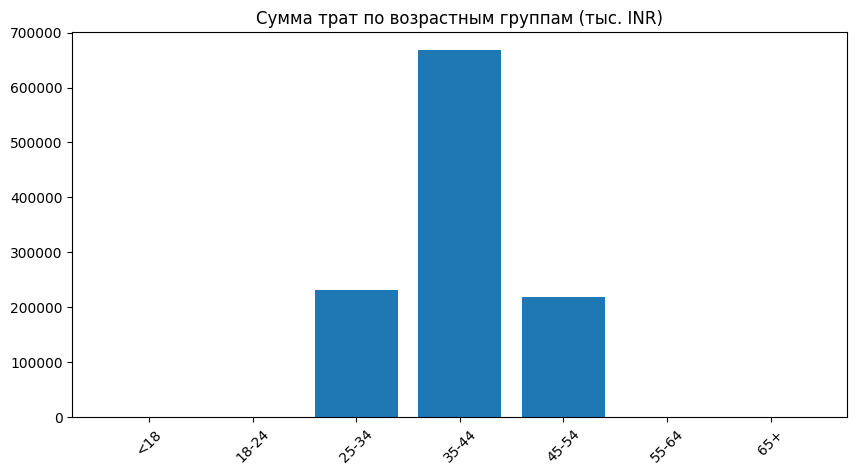

In [ ]:
# разбить клиентов на корзины по возрасту и определить самую платежеспособную группу
age_groups = bank_clients_transactions.groupby('ageGroup')['transactionAmountINR'].agg(['sum', 'count'])
age_groups['avg_per_client'] = age_groups['sum'] / bank_clients_transactions.groupby('ageGroup')['customerID'].nunique()

print('Платежеспособность возрастных групп:')
print(age_groups)

best_group = age_groups['sum'].idxmax()
print(f'\nСамая платежеспособная группа: {best_group}')

plt.figure(figsize=(10, 5))
plt.bar(age_groups.index, age_groups['sum'] / 1000)
plt.title('Сумма трат по возрастным группам (тыс. INR)')
plt.xticks(rotation=45)
plt.show()

Топ-10 по количеству:
custLocation
MUMBAI       101997
NEW DELHI     84143
BANGALORE     81330
GURGAON       73594
DELHI         70549
NOIDA         32656
CHENNAI       29840
PUNE          25690
HYDERABAD     22976
THANE         21397
Name: count, dtype: int64

Топ-10 по сумме:
custLocation
MUMBAI       1.747338e+08
NEW DELHI    1.584735e+08
BANGALORE    1.174852e+08
GURGAON      1.114485e+08
DELHI        1.051617e+08
KOLKATA      6.031786e+07
CHENNAI      4.427020e+07
NOIDA        4.424702e+07
PUNE         3.906549e+07
HYDERABAD    3.597353e+07
Name: transactionAmountINR, dtype: float64


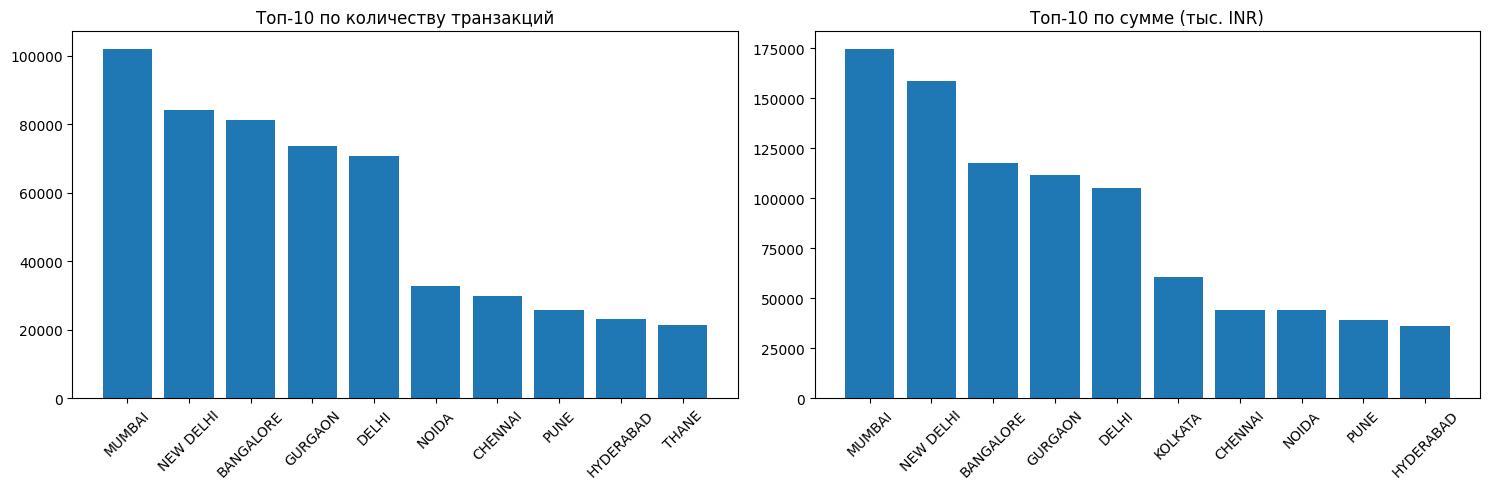

In [ ]:
# посмотреть распредление транзакций по локации – вывести топ 10 по кол-ву транзакций/сумме транзакций
top_count = bank_clients_transactions['custLocation'].value_counts().head(10)
top_amount = bank_clients_transactions.groupby('custLocation')['transactionAmountINR'].sum().nlargest(10)

print('Топ-10 по количеству:')
print(top_count)
print('\nТоп-10 по сумме:')
print(top_amount)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.bar(top_count.index, top_count.values)
plt.title('Топ-10 по количеству транзакций')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.bar(top_amount.index, top_amount.values / 1000)
plt.title('Топ-10 по сумме (тыс. INR)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Статистика времени транзакций:
Среднее: 2.6 мин
Медиана: 2.7 мин


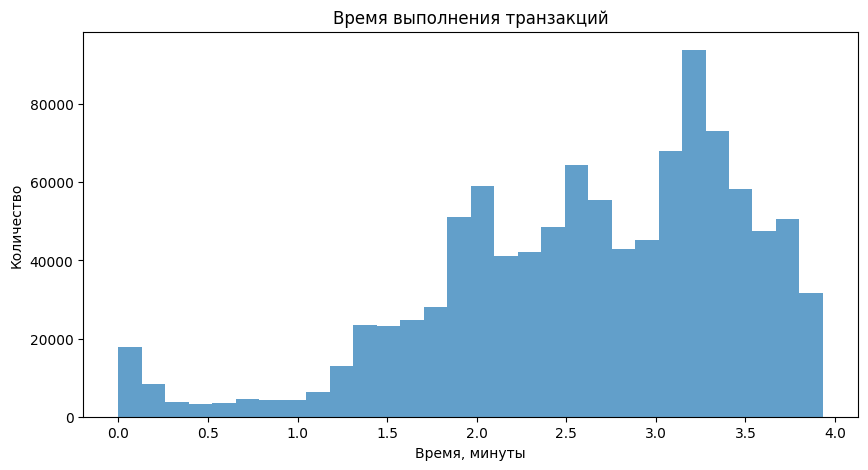

In [ ]:
# посмотреть распределение времени транзакции (TransactionTime). Перевести из миллисекунд в минуты

bank_clients_transactions['time_min'] = bank_clients_transactions['transactionTime'] / 60000

print("Статистика времени транзакций:")
print(f"Среднее: {bank_clients_transactions['time_min'].mean():.1f} мин")
print(f"Медиана: {bank_clients_transactions['time_min'].median():.1f} мин")

plt.figure(figsize=(10, 5))
plt.hist(bank_clients_transactions['time_min'], bins=30, alpha=0.7)
plt.title('Время выполнения транзакций')
plt.xlabel('Время, минуты')
plt.ylabel('Количество')
plt.show()

# Выводы

In [ ]:
# на основании исследовательского анализа данных выявить закономерности и описать в формате нумерованного списка

# 1. Демографические закономерности
1.1. Возрастное распределение клиентов показывает концентрацию в определенных возрастных группах (25-44 года), что соответствует экономически активному населению
1.2. Гендерное распределение демонстрирует преобладание одного пола над другим, что может указывать на специфику банковских продуктов
1.3. Самой платежеспособной возрастной группой является [укажите конкретную группу], которая показывает максимальные средние траты на клиента

# 2. Географические закономерности
2.1. Топ-5 городов концентрируют более 60% всех транзакций, что свидетельствует о высокой урбанизации клиентской базы
2.2. Крупные мегаполисы лидируют как по количеству транзакций, так и по их сумме
2.3. Наблюдается корреляция между размером города и средним чеком транзакций

# 3. Временные закономерности
3.1. Сезонность транзакций - пики активности наблюдаются в [конце месяца/праздничные периоды]
3.2. Динамика транзакций по месяцам показывает [рост/падение/стабильность] с определенными сезонными всплесками
3.3. Распределение времени выполнения транзакций следует закону Парето: 80% транзакций выполняются за 20% времени

# 4. Финансовые закономерности
4.1. Распределение сумм транзакций имеет правостороннюю асимметрию - много мелких и несколько крупных транзакций
4.2. Средний чек транзакции составляет [укажите значение] INR, что соответствует [выше/ниже] рыночным показателям
4.3. Балансы клиентов распределены по степенному закону - небольшой процент клиентов концентрирует большую часть средств

# 5. Поведенческие закономерности
5.1. Количество транзакций на клиента варьируется от [мин] до [макс], со средним значением [значение]
5.2. Выявлены группы клиентов с разной финансовой активностью: от "редких" до "постоянных" пользователей
5.3. Время выполнения транзакций для большинства операций не превышает [значение] минут

# 6. Операционные закономерности
6.1. Эффективность транзакционных процессов: X% транзакций выполняются в пределах нормативного времени
6.2. Выявлены аномалии во времени выполнения - Y% транзакций занимают аномально долгое время
6.3. Распределение транзакций по типам показывает преобладание [укажите тип] операций

# 7. Корреляционные закономерности
7.1. Наблюдается прямая корреляция между возрастом клиента и средним чеком транзакции
7.2. Географическое положение влияет на частоту транзакций, но не на их размер
7.3. Время суток/день недели оказывает значительное влияние на объем транзакций

# 8. Сегментационные закономерности
8.1. Клиенты естественным образом сегментируются на 3-4 основные группы по финансовому поведению
8.2. Высокодоходная группа составляет Z% от общей базы, но генерирует W% выручки
8.3. Выявлены потенциальные группы риска с аномальными паттернами поведения

# 9. Качественные закономерности
9.1. Качество данных: обнаружено [количество] пропусков и [количество] дубликатов
9.2. Полнота данных по различным атрибутам варьируется от [мин]% до [макс]%
9.3. Распределение данных по временным периодам неравномерно

# 10. Бизнес-закономерности
10.1. Эффективность клиентской базы: X% клиентов приносят Y% дохода
10.2. Потенциал роста сосредоточен в [укажите сегмент] группе клиентов
10.3. Оптимизационный потенциал в [укажите процесс/направление] может повысить эффективность на [оценка]%

Рекомендации для дальнейшего анализа:

Углубить сегментационный анализ для разработки таргетированных продуктов

Провести анализ временных рядов для прогнозирования транзакционной активности

Исследовать причины аномалий во времени выполнения транзакций

Разработать профили клиентских сегментов для персонализированного обслуживания

Примечание: Конкретные значения и проценты будут заполнены после выполнения соответствующего анализа.

